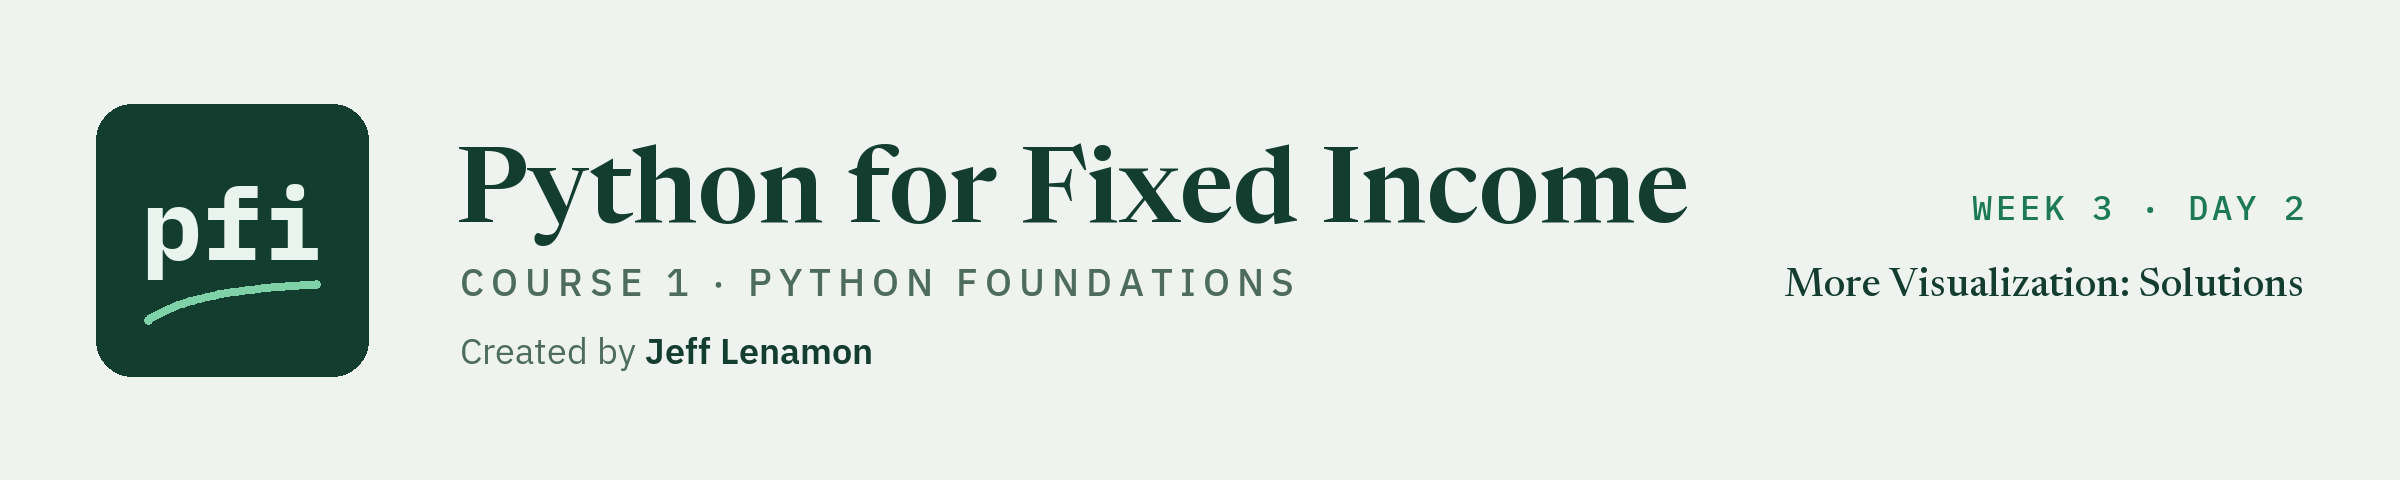

# More Visualization - Solutions

Week 3. Worked answers to the exercises. Try each one yourself first.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/week3/day2/12_visualization_more_solutions.ipynb)

## Exercises

The exercises use the same 200 bonds and ask about columns and pairs the lesson did not chart: the rating score, the price, the sectors, and the DTS. One of them asks for an interactive chart. The issuers are invented, and every answer describes the data and is not a view.

Each exercise asks for a chart and for one or two numbers that the chart should agree with. Replace each `...` with your own code, draw the chart in the same cell or a new one, then run the check cell. Give every chart a title and axis labels with units. Worked answers are in the solutions notebook in this folder.

Run the next cell first. It imports the libraries, loads fresh copies of the two tables, rebuilds `book` and `bucket_order`, and defines `check`, a small function that marks your answers. It prints the shape of the book, (200, 22), and the seven buckets in credit order.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
from matplotlib.ticker import PercentFormatter


def check(label, answer, expected):
    """Compare an exercise answer to the expected value and print the result."""
    if answer is ...:
        print(label + ': not attempted yet')
        return
    if isinstance(expected, list):
        # a list of values: the same values in the same order
        correct = list(answer) == expected
    elif isinstance(expected, float):
        # single numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 0.000001
    else:
        correct = answer == expected
    if correct:
        print(label + ': correct')
    else:
        print(label + ': not yet. You have', answer)


# fresh copies of the two tables. In Colab they are read from GitHub.
if os.path.exists('../../data/holdings.csv'):
    data_folder = '../../data/'
else:
    data_folder = 'https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/'

holdings = pd.read_csv(data_folder + 'holdings.csv')
ratings = pd.read_csv(data_folder + 'ratings.csv')

# the book, rebuilt: the holdings with the score, bucket, and grade of each rating
book = pd.merge(holdings, ratings, on='rating', how='left')
bucket_order = ratings.sort_values('score')['bucket'].unique().tolist()

print(book.shape)
print(bucket_order)

(200, 22)
['AAA', 'AA', 'A', 'BBB', 'BB', 'B', 'CCC']


### Exercise 1

Q. The `score` column numbers the ratings from 1 for AAA to 18 for CCC. Fit a straight line of `oas` on `score` with `np.polyfit()`, and draw it with `sns.regplot()`. What are the slope and the intercept, each rounded to 2 decimal places? Store them in **ex1_slope** and **ex1_intercept**.

Slope: 42.45 basis points per rating notch
Intercept: -211.63 basis points
R squared: 0.55
The line at score 1: -169.17 basis points


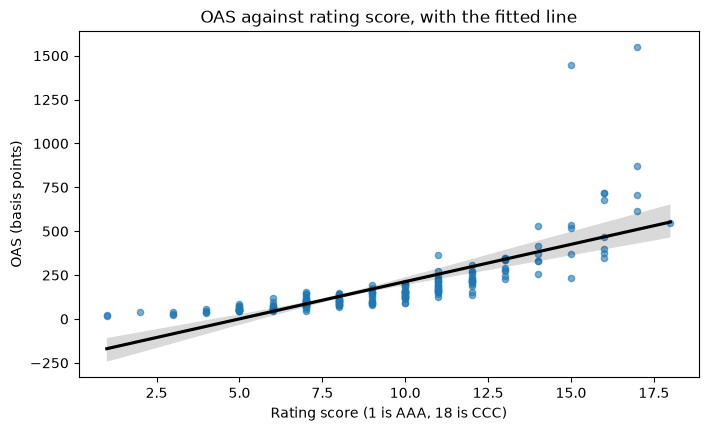

In [2]:
# x is the score and y is the OAS
slope, intercept = np.polyfit(book['score'], book['oas'], 1)

ex1_slope = round(slope, 2)
ex1_intercept = round(intercept, 2)

print('Slope:', ex1_slope, 'basis points per rating notch')
print('Intercept:', ex1_intercept, 'basis points')
print('R squared:', round(book['score'].corr(book['oas']) ** 2, 2))
print('The line at score 1:', round(intercept + slope * 1, 2), 'basis points')

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.regplot(data=book, x='score', y='oas', seed=0,
            scatter_kws={'s': 20, 'alpha': 0.6}, line_kws={'color': 'black'}, ax=ax)

ax.set_title('OAS against rating score, with the fitted line')
ax.set_xlabel('Rating score (1 is AAA, 18 is CCC)')
ax.set_ylabel('OAS (basis points)')

plt.show()

* The slope is 42.45 basis points per rating notch and the intercept is -211.63 basis points. R squared is 0.55.
* The intercept is negative, and so is the line at score 1: -169.17 basis points, for a rating whose two bonds are at about 21. A straight line is a poor description of a curve. Yesterday's line plot showed the OAS rising slowly through the high ratings and steeply through the low ones, and a single slope cannot do both.
* The fit runs without complaint all the same. The chart is what shows the problem: the points sit above the line at both ends and below it in the middle.

In [3]:
check('Exercise 1 slope', ex1_slope, 42.45)
check('Exercise 1 intercept', ex1_intercept, -211.63)

Exercise 1 slope: correct
Exercise 1 intercept: correct


### Exercise 2

Q. Draw a strip plot of `price` with one column for each rating bucket, in credit order. Set `np.random.seed(0)` first. What is the lowest price in the file, and which bucket is that bond in? Store the answers in **ex2_low** and **ex2_bucket**. The method `idxmin()` returns the row label of the smallest value in a Series.

Lowest price: 62.045 in bucket B
Bonds priced below 90: 21
           min      max
bucket                 
AAA     99.250  110.206
AA      89.614  119.131
A       76.903  118.201
BBB     73.873  117.164
BB      81.455  110.757
B       62.045  109.275
CCC     87.116  104.980


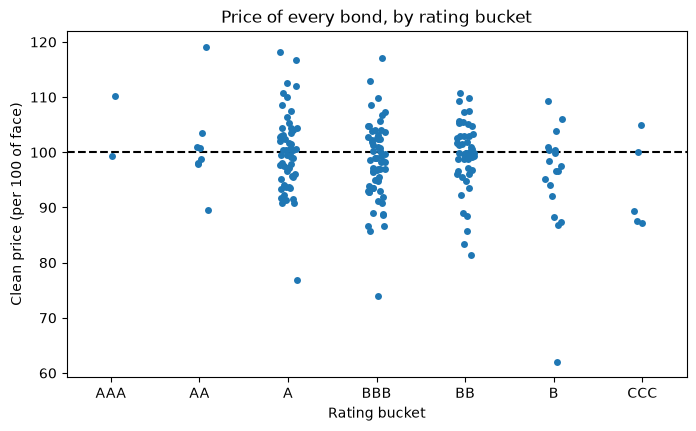

In [4]:
# the row with the lowest price
lowest = book.loc[book['price'].idxmin()]

ex2_low = lowest['price']
ex2_bucket = lowest['bucket']

print('Lowest price:', ex2_low, 'in bucket', ex2_bucket)
print('Bonds priced below 90:', (book['price'] < 90).sum())

# the lowest and the highest price in each bucket
print(book.groupby('bucket')['price'].agg(['min', 'max']).loc[bucket_order])

# the same sideways nudges on every run
np.random.seed(0)

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.stripplot(data=book, x='bucket', y='price', order=bucket_order, ax=ax)

# a reference line at a price of 100
ax.axhline(100, color='black', linestyle='--')

ax.set_title('Price of every bond, by rating bucket')
ax.set_xlabel('Rating bucket')
ax.set_ylabel('Clean price (per 100 of face)')

plt.show()

* The lowest price in the file is 62.045, and the bond is in the B bucket. It is the lowest point on the chart, well below every other.
* Every bucket has bonds on both sides of the dashed line at 100: in each row of the table the lowest price is below 100 and the highest is above it. That includes AAA, with its 2 bonds at 99.25 and 110.206. 21 of the 200 bonds are priced below 90.

In [5]:
check('Exercise 2 lowest price', ex2_low, 62.045)
check('Exercise 2 bucket', ex2_bucket, 'B')

Exercise 2 lowest price: correct
Exercise 2 bucket: correct


### Exercise 3

Q. Work out each sector's share of the book's market value, in percent. Draw the shares as horizontal bars with the largest at the top, a percent format on the x axis, and the value written on each bar. Which sector has the largest share, and what is it, rounded to 1 decimal place? Store the answers in **ex3_sector** and **ex3_share**.

sector
Utilities          5.9
Technology         6.2
Energy             7.9
Health Care        7.9
Transportation     9.9
Industrials       10.7
Telecom           11.4
Consumer          11.5
Financials        13.9
Materials         14.6
Name: market_value, dtype: float64


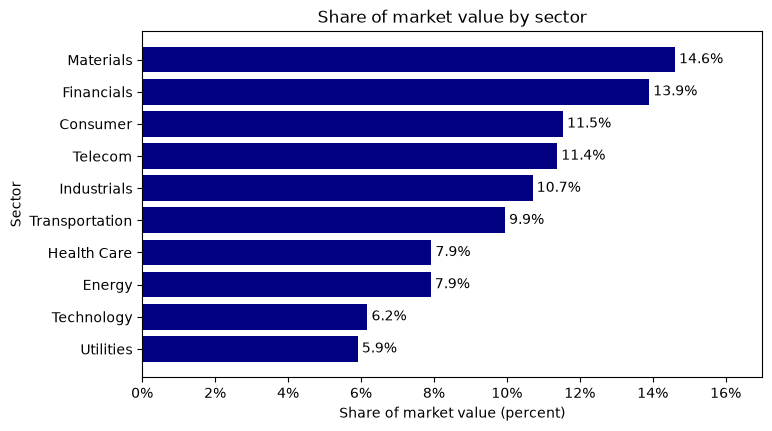

In [6]:
# each sector's market value as a percentage of the total, smallest first
value_by_sector = book.groupby('sector')['market_value'].sum()
share_by_sector = (value_by_sector / value_by_sector.sum() * 100).sort_values()
print(share_by_sector.round(1))

ex3_sector = share_by_sector.idxmax()
ex3_share = round(share_by_sector.max(), 1)

fig, ax = plt.subplots(figsize=(8, 4.5))

# barh() draws from the bottom up, so the largest share, sorted last, is at the top
bars = ax.barh(share_by_sector.index, share_by_sector.values, color='navy')
ax.bar_label(bars, fmt='%.1f%%', padding=3)

# the percent format goes on the x axis, because the bars are horizontal
ax.xaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
ax.set_xlim(0, 17)

ax.set_title('Share of market value by sector')
ax.set_xlabel('Share of market value (percent)')
ax.set_ylabel('Sector')

plt.show()

* Materials has the largest share, 14.6 percent of the book's market value. Financials is next at 13.9 percent, and Utilities is the smallest at 5.9 percent.
* The order of the bars is the order of yesterday's chart in millions of dollars. Dividing every bar by the same total changes the axis and not the picture.

In [7]:
check('Exercise 3 sector', ex3_sector, 'Materials')
check('Exercise 3 share', ex3_share, 14.6)

Exercise 3 sector: correct
Exercise 3 share: correct


### Exercise 4

Q. Draw an interactive scatter plot with plotly: `duration` on the x axis and `dts` on the y axis, coloured by grade, with the issuer name as the heading of the hover box and the ticker and rating inside it. Point at the highest point on the chart. What is that bond's ticker, and what is its DTS? Confirm both with code, using `idxmax()`, and store them in **ex4_ticker** and **ex4_dts**.

In [8]:
# the row with the highest DTS
top = book.loc[book['dts'].idxmax()]

ex4_ticker = top['ticker']
ex4_dts = top['dts']

print('Highest DTS:', ex4_ticker, '-', top['issuer'], '- rating', top['rating'])
print('Duration:', top['duration'], 'years, OAS:', top['oas'], 'bp, DTS:', ex4_dts)
print('Median DTS of the book:', book['dts'].median())

fig = px.scatter(book, x='duration', y='dts', color='grade',
                 hover_name='issuer', hover_data=['ticker', 'rating'],
                 labels={'duration': 'Duration (years)', 'dts': 'DTS (duration times spread)',
                         'grade': 'Grade', 'ticker': 'Ticker', 'rating': 'Rating'},
                 title='DTS against duration, one point per bond',
                 width=800, height=450)

fig.show()

Highest DTS: CLDB - Calderby Retail - rating B
Duration: 4.513 years, OAS: 1446 bp, DTS: 6525.8
Median DTS of the book: 811.0


* The highest point is headed Calderby Retail, an invented issuer. Its ticker is CLDB and its DTS is 6,525.8, at a duration of 4.513 years. The hover box and the code agree.
* The highest DTS is not on a long bond. DTS is duration times spread, and this row has the second widest OAS in the file, 1,446 basis points. The median DTS of the book is 811.0, so this one row is far above the crowd along the bottom of the chart.
* The interactive chart appears when the cell is run. GitHub's preview may show nothing in its place.

In [9]:
check('Exercise 4 ticker', ex4_ticker, 'CLDB')
check('Exercise 4 DTS', ex4_dts, 6525.8)

Exercise 4 ticker: correct
Exercise 4 DTS: correct


### Exercise 5: AI check

You ask an AI assistant to fit a straight line of yield on coupon across the book, draw it over the bonds, and say how much yield goes with each extra point of coupon. It gives you the code below. It was written for this course in the style of an AI assistant's answer. It contains one bug.

Q. Read the code before you run it. What slope should it report? The lesson worked it out in section 12.2. Then run the code. Does the answer agree with you?

* The lesson's slope of yield on coupon is 0.88. The original code reported 0.63, with no error, and drew a line that passed through the cloud and looked reasonable.
* The bug was the order of the first two arguments. `np.polyfit()` takes x first and y second. The code passed the yield first and the coupon second, so it fitted the coupon as a function of the yield: 0.63 points of coupon for each point of yield. It then drew that line on a chart with the coupon along the x axis, where it does not belong.
* The two slopes are not two ways of writing one number. Turning 0.63 upside down gives about 1.6, not 0.88. Multiplied together, 0.88 and 0.63 give 0.55, which is R squared. The two fits agree only when every point is on the line.
* Excel has the opposite convention: `=SLOPE(known_ys, known_xs)` takes y first. Moving between the two is where this slip comes from.
* The fix is to pass the coupon first. The check that caught it was one number worked out earlier and compared with the output.

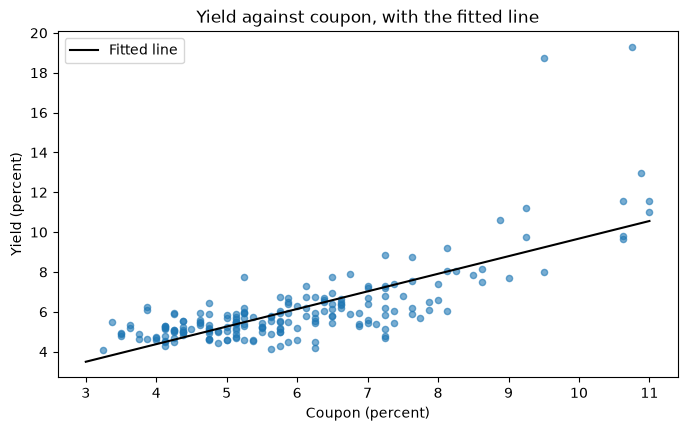

Each extra point of coupon goes with 0.88 points of yield


In [10]:
# straight-line fit of yield on coupon: x is the coupon and y is the yield
slope, intercept = np.polyfit(book['coupon'], book['yield_pct'], 1)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(book['coupon'], book['yield_pct'], s=20, alpha=0.6)

# the fitted line between a coupon of 3 percent and 11 percent
line_x = np.array([3, 11])
ax.plot(line_x, intercept + slope * line_x, color='black', label='Fitted line')

ax.legend()
ax.set_title('Yield against coupon, with the fitted line')
ax.set_xlabel('Coupon (percent)')
ax.set_ylabel('Yield (percent)')

plt.show()

ex5_slope = round(slope, 2)
print('Each extra point of coupon goes with', ex5_slope, 'points of yield')

In [11]:
check('Exercise 5 slope', ex5_slope, 0.88)

Exercise 5 slope: correct
